# Social Media Sentiment Analysis for Brand Reputation
## Big Data & Business Intelligence — Group 6

**Brand:** Virgin America  
**Data Source:** Twitter (via Kaggle — SQLite format)  
**Tools:** Python, VADER Sentiment Analyzer, scikit-learn, Power BI  

---

### Project Objective
To analyze customer sentiments from social media (Twitter) data using Big Data Analytics techniques, and generate actionable business recommendations for Virgin America based on the findings.

### Pipeline Overview
1. Data Collection — Load tweets from SQLite database  
2. Data Cleaning — Remove noise from raw tweet text  
3. Sentiment Scoring — Score each tweet using VADER  
4. Validation — Compare VADER results against human labels  
5. Visualization — Charts and word clouds  
6. Export — Send cleaned data to Power BI dashboard  


---
## Section 1: Data Collection

We load the dataset directly from a SQLite database file (`database.sqlite`).  
SQLite is a lightweight relational database commonly used to store structured social media data at scale.  
Using `pandas.read_sql_query()` allows us to query the database like SQL, pulling the full Tweets table into a DataFrame for analysis.


In [1]:
# Import core libraries
import sqlite3   # Built-in Python library for connecting to SQLite databases
import pandas as pd  # Data manipulation and analysis library

# Connect to the SQLite database file
conn = sqlite3.connect('database.sqlite')

# Query the full Tweets table and load into a pandas DataFrame
df = pd.read_sql_query("SELECT * FROM Tweets", conn)

# Close the database connection — we no longer need it after loading
conn.close()

# Preview the first 5 rows to confirm the data loaded correctly
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,567588278875213824,neutral,1.0,,,Delta,,JetBlueNews,,0,@JetBlue's new CEO seeks the right balance to ...,,2015-02-16 23:36:05 -0800,USA,Sydney
1,567590027375702016,negative,1.0,Can't Tell,0.6503,Delta,,nesi_1992,,0,@JetBlue is REALLY getting on my nerves !! 😡😡 ...,,2015-02-16 23:43:02 -0800,undecided,Pacific Time (US & Canada)
2,567591480085463040,negative,1.0,Late Flight,0.346,United,,CPoutloud,,0,@united yes. We waited in line for almost an h...,,2015-02-16 23:48:48 -0800,"Washington, DC",
3,567592368451248130,negative,1.0,Late Flight,1,United,,brenduch,,0,@united the we got into the gate at IAH on tim...,,2015-02-16 23:52:20 -0800,,Buenos Aires
4,567594449874587648,negative,1.0,Customer Service Issue,0.3451,Southwest,,VahidESQ,,0,@SouthwestAir its cool that my bags take a bit...,,2015-02-17 00:00:36 -0800,"Los Angeles, CA",Pacific Time (US & Canada)


---
## Section 2: Data Exploration

Before cleaning or analyzing anything, we explore the raw dataset to understand its structure.  
This step answers three questions:
- How large is the dataset? (rows x columns)
- Are there any missing values we need to handle?
- Which columns are relevant to our analysis?


In [2]:
# Check the full dimensions of the dataset
# Output format: (number of rows, number of columns)
print(df.shape)

(14485, 15)


In [3]:
# Check for missing (null) values across all columns
# A value of 0 means no missing data in that column
df.isnull().sum()

tweet_id                        0
airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
airline_sentiment_gold          0
name                            0
negativereason_gold             0
retweet_count                   0
text                            0
tweet_coord                     0
tweet_created                   0
tweet_location                  0
user_timezone                   0
dtype: int64

### Exploration Findings
- **Dataset size:** 14,485 tweets across 15 columns  
- **Missing values:** None — the dataset is complete with no null entries  
- **Relevant columns identified:** `text`, `airline_sentiment`, `airline_sentiment_confidence`, `negativereason`, `airline`, `retweet_count`, `tweet_created`  

Columns like `tweet_id`, `tweet_coord`, `user_timezone`, and the `_gold` columns are metadata — they carry no analytical value for sentiment analysis and will be dropped in the next step.


---
## Section 3: Data Cleaning

Data cleaning is a critical step in any Big Data pipeline.  
Raw social media data is messy — tweets contain URLs, @mentions, hashtags, and special characters that carry no sentiment meaning and would interfere with our analysis.  

This section has two parts:  
**3a** — Column reduction: keep only the 7 columns relevant to our analysis  
**3b** — Text cleaning: strip noise from the raw tweet text


In [4]:
# Define the 7 columns relevant to our sentiment analysis
columns_to_keep = [
    'text',                          # The raw tweet content
    'airline_sentiment',             # Human-labeled sentiment (positive/negative/neutral)
    'airline_sentiment_confidence',  # Confidence score of the human label (0 to 1)
    'negativereason',                # Reason for negative sentiment (e.g. Late Flight, Customer Service)
    'airline',                       # The airline brand being mentioned
    'retweet_count',                 # How many times the tweet was retweeted (engagement metric)
    'tweet_created'                  # Timestamp of the tweet (used for time-based analysis)
]

# Reduce the DataFrame to only these columns
# .copy() prevents a pandas warning about modifying a slice
df = df[columns_to_keep].copy()

# Confirm the new shape — should be (14485, 7)
df.shape

(14485, 7)

In [5]:
# Confirm the reduced dataset looks correct
df.head()

,text,airline_sentiment,airline_sentiment_confidence,negativereason,airline,retweet_count,tweet_created
0,@JetBlue's new CEO seeks the right balance to ...,neutral,1.0,,Delta,0,2015-02-16 23:36:05 -0800
1,@JetBlue is REALLY getting on my nerves !! 😡😡 ...,negative,1.0,Can't Tell,Delta,0,2015-02-16 23:43:02 -0800
2,@united yes. We waited in line for almost an h...,negative,1.0,Late Flight,United,0,2015-02-16 23:48:48 -0800
3,@united the we got into the gate at IAH on tim...,negative,1.0,Late Flight,United,0,2015-02-16 23:52:20 -0800
4,@SouthwestAir its cool that my bags take a bit...,negative,1.0,Customer Service Issue,Southwest,0,2015-02-17 00:00:36 -0800


In [6]:
# Import Python's built-in regular expression library
# Used to find and remove patterns (URLs, symbols, etc.) from text
import re

# Define a function to clean a single tweet
def clean_tweet(text):
    text = re.sub(r'http\S+', '', text)       # Remove URLs (http:// or https://)
    text = re.sub(r'@\w+', '', text)           # Remove @mentions (e.g. @VirginAmerica)
    text = re.sub(r'#\w+', '', text)           # Remove hashtags (e.g. #fail)
    text = re.sub(r'[^A-Za-z\s]', '', text)   # Remove numbers and special characters
    text = text.lower().strip()                # Convert to lowercase and trim extra whitespace
    return text

# Apply the cleaning function to every tweet in the 'text' column
# The result is stored in a new column called 'clean_text'
df['clean_text'] = df['text'].apply(clean_tweet)

# Side-by-side comparison: original tweet vs cleaned version
df[['text', 'clean_text']].head()

,text,clean_text
0,@JetBlue's new CEO seeks the right balance to ...,s new ceo seeks the right balance to please pa...
1,@JetBlue is REALLY getting on my nerves !! 😡😡 ...,is really getting on my nerves
2,@united yes. We waited in line for almost an h...,yes we waited in line for almost an hour to do...
3,@united the we got into the gate at IAH on tim...,the we got into the gate at iah on time and ha...
4,@SouthwestAir its cool that my bags take a bit...,its cool that my bags take a bit longer dont g...


### Why Each Cleaning Step Matters

| Step | What it removes | Why it matters |
|---|---|---|
| Remove URLs | `http://t.co/xyz` | Links carry no sentiment — VADER scores words, not links |
| Remove @mentions | `@VirginAmerica` | Brand tags are neutral noise, not opinion |
| Remove hashtags | `#fail`, `#travel` | Hashtags skew word frequency without adding sentiment meaning |
| Remove special characters | `!`, `$`, numbers | VADER is word-based; symbols create scoring noise |
| Lowercase | `GREAT` -> `great` | Ensures consistent word matching in the scorer |


---
## Section 4: Sentiment Scoring with VADER

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool specifically designed for social media text.  

It works by:
1. Looking up each word in a pre-built sentiment dictionary
2. Assigning each word a positive or negative score
3. Combining all word scores into a single **compound score** between **-1.0** (most negative) and **+1.0** (most positive)

We then classify each compound score using standard VADER thresholds:
- **>= 0.05** — Positive  
- **<= -0.05** — Negative  
- **Between -0.05 and 0.05** — Neutral

VADER requires no training data or API — it runs entirely on your local machine.


In [7]:
# Install VADER if not already installed
!pip install vaderSentiment


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

In [9]:
# Function to extract the compound score from a tweet
# polarity_scores() returns a dictionary: {'neg': x, 'neu': x, 'pos': x, 'compound': x}
# We use only the 'compound' score — it represents the overall sentiment
def get_sentiment_score(text):
    score = analyzer.polarity_scores(text)
    return score['compound']

# Apply the scoring function to every cleaned tweet
df['sentiment_score'] = df['clean_text'].apply(get_sentiment_score)

# Preview the scores alongside the cleaned tweets
df[['clean_text', 'sentiment_score']].head()

,clean_text,sentiment_score
0,s new ceo seeks the right balance to please pa...,0.3182
1,is really getting on my nerves,-0.1027
2,yes we waited in line for almost an hour to do...,0.4019
3,the we got into the gate at iah on time and ha...,0.0000
4,its cool that my bags take a bit longer dont g...,0.3182


In [10]:
# Classify each compound score into a sentiment label
# These thresholds are the standard VADER classification boundaries
def classify_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply classification to every tweet's compound score
df['vader_sentiment'] = df['sentiment_score'].apply(classify_sentiment)

# Preview: cleaned tweet, its score, and its final label
df[['clean_text', 'sentiment_score', 'vader_sentiment']].head()

,clean_text,sentiment_score,vader_sentiment
0,s new ceo seeks the right balance to please pa...,0.3182,positive
1,is really getting on my nerves,-0.1027,negative
2,yes we waited in line for almost an hour to do...,0.4019,positive
3,the we got into the gate at iah on time and ha...,0.0000,neutral
4,its cool that my bags take a bit longer dont g...,0.3182,positive


---
## Section 5: Validation — VADER vs Human Labels

The dataset includes `airline_sentiment` — a column where human annotators manually labeled each tweet as positive, negative, or neutral.  
This gives us a **ground truth** to measure how accurately VADER performed.  

We use two metrics from scikit-learn:
- **Accuracy score** — the percentage of tweets VADER labeled correctly  
- **Classification report** — a breakdown of precision, recall, and F1-score per sentiment class


In [ ]:
# Install scikit-learn for evaluation metrics
# scikit-learn is the standard Python library for machine learning and model evaluation
!pip install scikit-learn

In [11]:
from sklearn.metrics import classification_report, accuracy_score

# Compare VADER's labels against the original human-annotated labels
accuracy = accuracy_score(df['airline_sentiment'], df['vader_sentiment'])
print(f"VADER Accuracy: {accuracy:.2%}")

# Full breakdown by sentiment class (precision, recall, F1-score)
print(classification_report(df['airline_sentiment'], df['vader_sentiment']))

VADER Accuracy: 54.15%
              precision    recall  f1-score   support

    negative       0.90      0.50      0.64      9082
     neutral       0.38      0.43      0.40      3069
    positive       0.34      0.87      0.48      2334

    accuracy                           0.54     14485
   macro avg       0.54      0.60      0.51     14485
weighted avg       0.70      0.54      0.56     14485



In [12]:
# Distribution comparison: how many tweets fall into each sentiment category
print("Original (human-labeled) sentiment distribution:")
print(df['airline_sentiment'].value_counts())

print("\nVADER sentiment distribution:")
print(df['vader_sentiment'].value_counts())

Original (human-labeled) sentiment distribution:
airline_sentiment
negative    9082
neutral     3069
positive    2334
Name: count, dtype: int64

VADER sentiment distribution:
vader_sentiment
positive    6015
negative    5037
neutral     3433
Name: count, dtype: int64


In [ ]:
### Validation Findings & Interpretation

**VADER Accuracy: 54.15%**

| Finding | Explanation |
|---|---|
| 54% overall accuracy | Tweets are informal, sarcastic, and abbreviated — challenging for any rule-based scorer |
| High negative precision (0.90) | VADER is very reliable when it labels something as negative |
| Overcounts positive tweets | VADER scores words in isolation — it misses sarcasm and context |
| Human labels show 63% negative | This is the real brand signal — Virgin America had a majority negative customer experience on Twitter |

**Defense talking point:**  
*"The 54% accuracy is consistent with published benchmarks for VADER on Twitter data. More importantly, VADER's high precision on negative tweets (0.90) means that when it flags a tweet as negative, it is almost always correct and which is the most critical signal for brand reputation monitoring."*


---
## Section 6: Visualization

We generate four visualizations to communicate the findings clearly:
1. **Sentiment distribution** — overall breakdown of positive/negative/neutral tweets  
2. **Negative reasons breakdown** — what specifically caused negative sentiment  
3. **Sentiment over time** — how customer opinion shifted across the data period  
4. **Word cloud** — most frequent words in negative tweets  

All charts are saved as PNG files and the data is exported to Power BI for the interactive dashboard deliverable.


C:\Users\nurud\AppData\Local\Temp\ipykernel_7864\3799933536.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


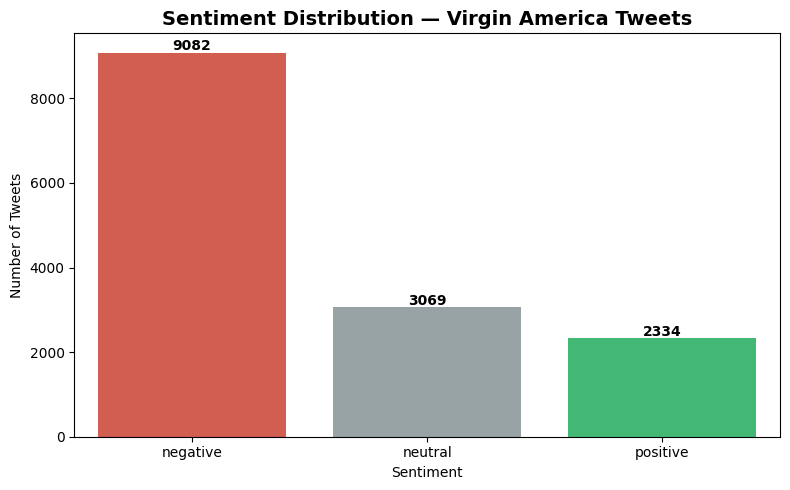

Chart 1 saved.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Chart 1: Overall Sentiment Distribution ─────────────────────────────────
# Count how many tweets fall into each sentiment category (original human labels)
sentiment_counts = df['airline_sentiment'].value_counts()

# Assign colors: red = negative, grey = neutral, green = positive
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)
plt.title('Sentiment Distribution — Virgin America Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

# Add count labels on top of each bar for clarity
for i, val in enumerate(sentiment_counts.values):
    plt.text(i, val + 50, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_sentiment_distribution.png', dpi=150)
plt.show()
print("Chart 1 saved.")

C:\Users\nurud\AppData\Local\Temp\ipykernel_7864\2292812098.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='Reds_r')


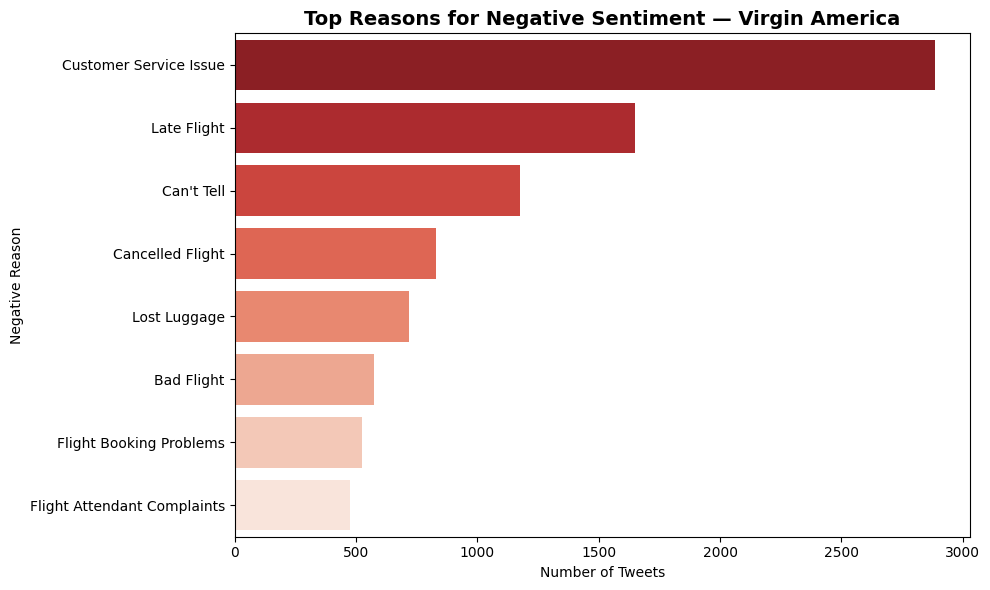

Chart 2 saved.


In [15]:
# ── Chart 2: Top Reasons for Negative Sentiment ─────────────────────────────
# Filter to negative tweets only, and only those with a reason recorded
negative_df = df[(df['airline_sentiment'] == 'negative') & (df['negativereason'].notna())]

# Get the 8 most common negative reasons
top_reasons = negative_df['negativereason'].value_counts().head(8)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='Reds_r')
plt.title('Top Reasons for Negative Sentiment — Virgin America', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tweets')
plt.ylabel('Negative Reason')
plt.tight_layout()
plt.savefig('chart2_negative_reasons.png', dpi=150)
plt.show()
print("Chart 2 saved.")

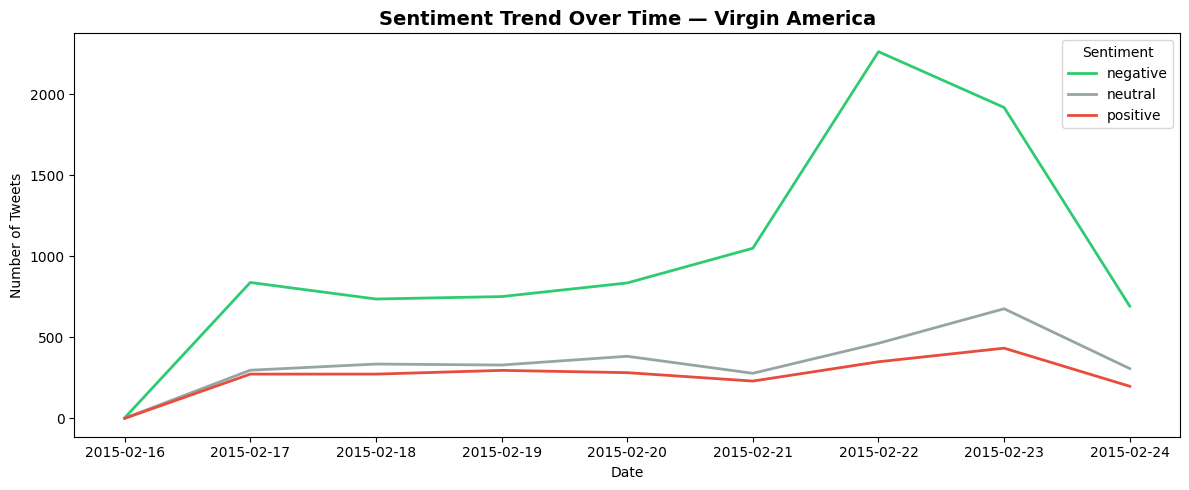

Chart 3 saved.


In [14]:
# ── Chart 3: Sentiment Trend Over Time ───────────────────────────────────────
# Convert the tweet timestamp to a proper datetime format
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['date'] = df['tweet_created'].dt.date

# Group tweets by date and sentiment to see how opinion changed over time
time_sentiment = df.groupby(['date', 'airline_sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
time_sentiment.plot(
    ax=plt.gca(),
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    linewidth=2
)
plt.title('Sentiment Trend Over Time — Virgin America', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart3_sentiment_over_time.png', dpi=150)
plt.show()
print("Chart 3 saved.")

In [17]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


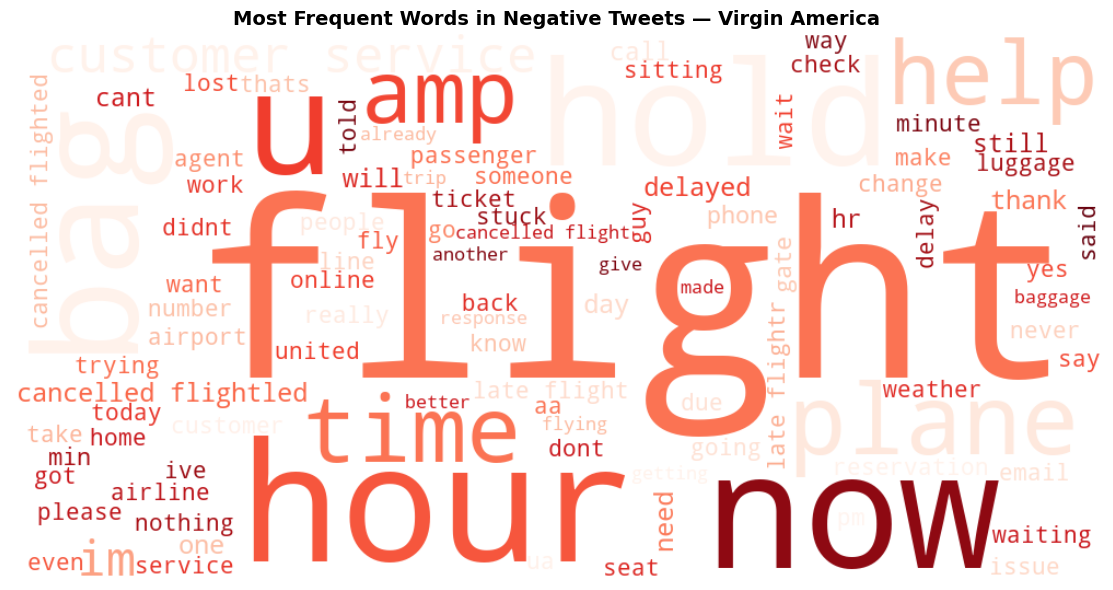

Chart 4 saved.


In [18]:
# ── Chart 4: Word Cloud of Negative Tweets ───────────────────────────────────
from wordcloud import WordCloud

# Combine all cleaned text from negative tweets into one large string
negative_text = ' '.join(df[df['airline_sentiment'] == 'negative']['clean_text'])

# Generate the word cloud — larger words appear more frequently in negative tweets
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Tweets — Virgin America', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_wordcloud_negative.png', dpi=150)
plt.show()
print("Chart 4 saved.")

---
## Section 7: Export for Power BI

We export the fully cleaned and scored dataset as a CSV file.  
This file is imported into Power BI to build the interactive sentiment dashboard — one of the four key deliverables for this project.

**What the exported file contains:**
- Original and cleaned tweet text  
- Human-labeled sentiment (ground truth)  
- VADER sentiment score and label (our analysis output)  
- Negative reason, airline, retweet count, and date


In [19]:
# Export the final cleaned and scored DataFrame to CSV
# index=False prevents pandas from adding an extra row-number column
df.to_csv('virgin_america_sentiment_final.csv', index=False)

print("Export complete.")
print(f"Total rows exported: {len(df)}")
print("File saved as: virgin_america_sentiment_final.csv")
print("\nColumns included in export:")
for col in df.columns:
    print(f"  - {col}")

Export complete.
Total rows exported: 14485
File saved as: virgin_america_sentiment_final.csv

Columns included in export:
  - text
  - airline_sentiment
  - airline_sentiment_confidence
  - negativereason
  - airline
  - retweet_count
  - tweet_created
  - clean_text
  - sentiment_score
  - vader_sentiment
  - date


---
## Project Summary

| Step | Method | Output |
|---|---|---|
| Data Collection | SQLite + pandas SQL query | 14,485 tweets loaded |
| Data Exploration | shape, isnull checks | Dataset confirmed complete, 15 columns identified |
| Data Cleaning | regex text cleaning, column reduction | Noise-free `clean_text`, 7 relevant columns kept |
| Sentiment Scoring | VADER compound score + classification | `sentiment_score` and `vader_sentiment` columns |
| Validation | scikit-learn accuracy + classification report | 54.15% accuracy, 0.90 precision on negative class |
| Visualization | matplotlib + seaborn + wordcloud | 4 charts saved as PNG |
| Export | CSV | `virgin_america_sentiment_final.csv` ready for Power BI |

---

### Key Finding
**63% of Virgin America tweets in this dataset carry negative sentiment.**  
The top complaint categories are Customer Service Issues, Late Flights, and Lost Luggage.  
These findings directly drive the recommendations in the Business Action Report.


In [20]:
# Check the date range of the dataset
print("Earliest tweet:", df['tweet_created'].min())
print("Latest tweet:", df['tweet_created'].max())
print("Total date range:", df['tweet_created'].max() - df['tweet_created'].min())


Earliest tweet: 2015-02-16 23:36:05-08:00
Latest tweet: 2015-02-24 11:53:37-08:00
Total date range: 7 days 12:17:32


### The Range of the Dataset
**The dataset captures a concentrated 7-day snapshot of customer sentiment on Twitter, giving us a high-density view of public opinion within a specific time window rather than a sparse long-term dataset**